In [2]:
from paralled_feature_extraction import extract_features_for_dataset
import crunch

# Load the Crunch Toolings (data loader, local tester, submitter).
crunch_tools = crunch.load_notebook()

# Load the data.
train_data, test_data = crunch_tools.load_data()
del test_data

loaded inline runner with module: <module '__main__'>

cli version: 11.4.1
available ram: 39.36 gb
available cpu: 16 core
----
data\X_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_train.parquet (218514418 bytes)
data\X_train.parquet: already exists, file length match
data\X_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/X_test.reduced.parquet (2587435 bytes)
data\X_test.reduced.parquet: already exists, file length match
data\y_train.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_train.parquet (8356193 bytes)
data\y_train.parquet: already exists, file length match
data\y_test.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/234/y_test.reduced.parquet (106299 bytes)
data\y_test.reduced.parquet: already exists, file

In [5]:
df = extract_features_for_dataset(train_data[:1000])

Training Feat. Extraction: 100%|██████████| 1000/1000 [09:28<00:00,  1.76it/s]


In [ ]:
#df.to_parquet("reduced_traning_set.parquet", index=False)

In [28]:
cols = [col for col in df.columns if col not in ['series_id', 't', 'target']]

In [24]:
'series_id' in cols

False

In [29]:
y = df.target
X = df[cols]

In [32]:
training_cols = X.columns


Feature importance ranking:
                     feature     importance  rank
0          running_max_abs_z  814997.687323     1
1              n_online_seen  595717.992554     2
2         running_mean_abs_z  281408.118859     3
3          max_abs_diff_w128  217229.819373     4
4         autocorr_lag2_w128  158743.204422     5
..                       ...            ...   ...
248              kurtosis_w8       0.000000   249
249                 mean_w16       0.000000   250
250                  std_w16       0.000000   251
251               median_w16       0.000000   252
252  abs_z_mean_diff_w8_w128       0.000000   253

[253 rows x 3 columns]


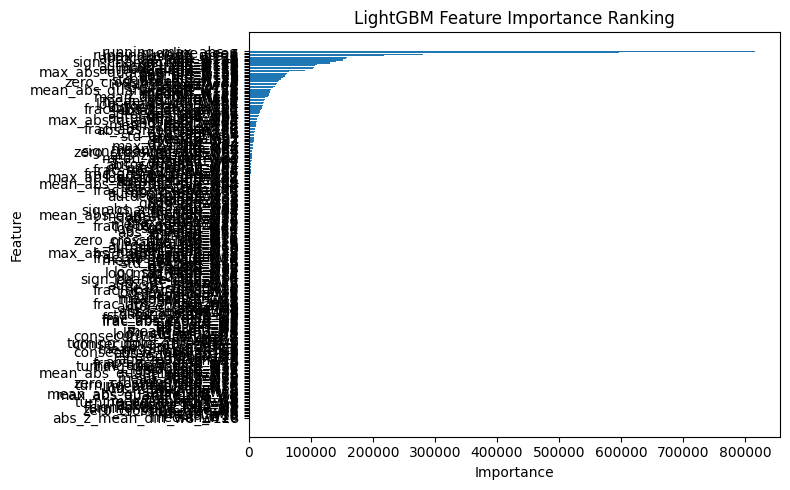

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier


# ----------------------------------------------------
# 3. Train LightGBM classifier
# ----------------------------------------------------
model = LGBMClassifier(
    objective="binary",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1,
    max_depth=-1,
    random_state=42,
    importance_type="gain"  # "gain" is usually better than "split"
)

model.fit(X, y)


# ----------------------------------------------------
# 6. Feature importance rank
# ----------------------------------------------------
importance_df = pd.DataFrame({
    "feature": training_cols,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

importance_df["rank"] = importance_df.index + 1

print("\nFeature importance ranking:")
print(importance_df)


# ----------------------------------------------------
# 7. Plot feature importance
# ----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importance Ranking")
plt.tight_layout()
plt.show()

In [37]:
importance_df[importance_df.importance  == 0]

,feature,importance,rank
182,median_w8,0.0,183
183,frac_abs_z_gt_1_w8,0.0,184
184,frac_abs_z_gt_3_w8,0.0,185
185,frac_abs_z_gt_2_w8,0.0,186
186,std_w8,0.0,187
...,...,...,...
248,kurtosis_w8,0.0,249
249,mean_w16,0.0,250
250,std_w16,0.0,251
251,median_w16,0.0,252
